In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3080 Ti'

In [4]:
from make import load_secondary_data

all_spectrograms, all_labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [5]:
len(all_labels)

600

In [6]:
len(all_spectrograms)

600

In [7]:
from validation_util import split, get_label_index

valid_spec, valid_labels = split(all_spectrograms, all_labels, 60)

In [8]:
len(all_spectrograms)

540

In [9]:
print(f'Initial shape of a spectrogram: ', all_spectrograms[0].shape)

ch, freq_bins = all_spectrograms[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')
print(f'Input Type: {type(all_spectrograms[0])}')


Initial shape of a spectrogram:  (129, 35)
Final shape: (129, 9)
Input Type: <class 'numpy.ndarray'>


In [10]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def get_x(i : int):
        arr = all_spectrograms[i]

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr.shape) == 3:
                arr = np.mean(arr, axis=-1)  # average across channels
        
        #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return all_labels[i]

In [12]:
from plot_util import PlotUtil

plotUtil = PlotUtil(spectrograms=all_spectrograms)

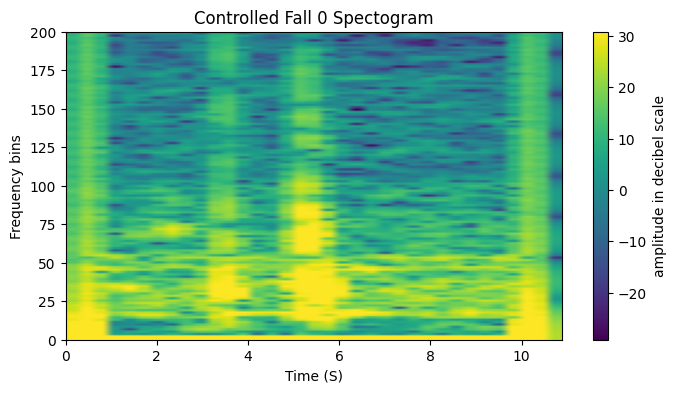

In [40]:
plotUtil.show_spec(get_label_index('Controlled Fall', all_labels), title=f'Controlled Fall {get_label_index('Controlled Fall', all_labels)} Spectogram')

<Axes: >

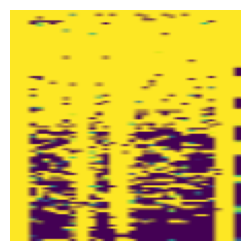

In [41]:
get_x(0).show()

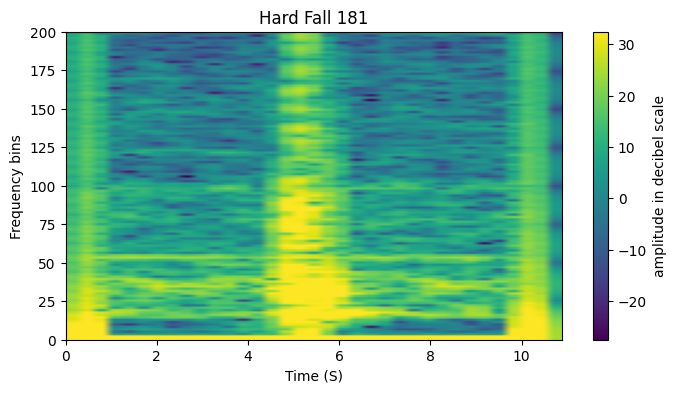

In [39]:
plotUtil.show_spec(get_label_index("Hard Fall", all_labels), title=f'Hard Fall {get_label_index("Hard Fall", all_labels)}')

<Axes: >

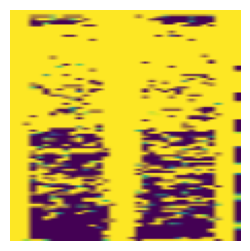

In [37]:
get_x(181).show()

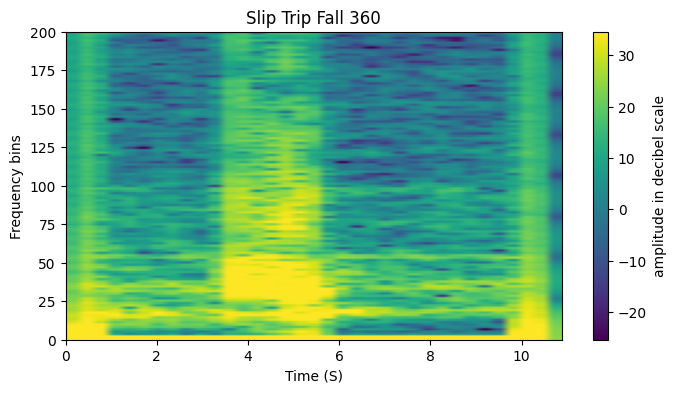

In [16]:
plotUtil.show_spec(get_label_index("SlipTrip", all_labels), title=f'Slip Trip Fall {get_label_index("SlipTrip", all_labels)}')


<Axes: >

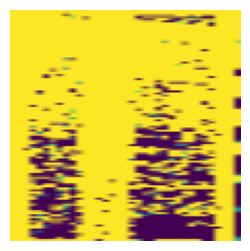

In [38]:
get_x(360).show()

In [17]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [254]:
len(all_labels)

540

In [18]:
items = list(range(len(all_spectrograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=16)

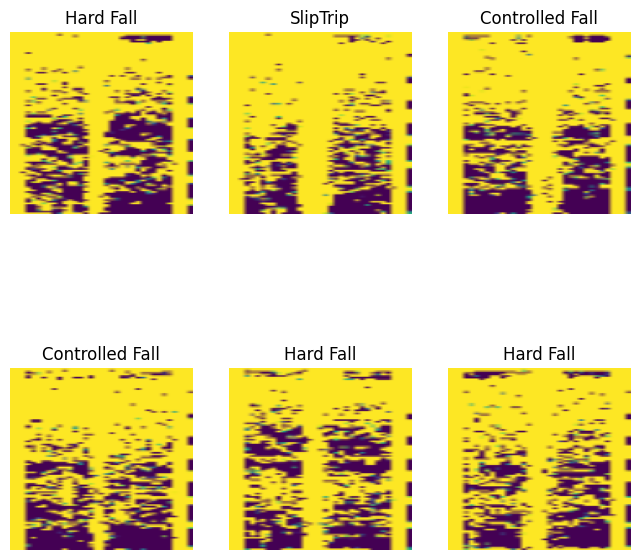

In [19]:
dls.show_batch(max_n=6, figsize=(8,8))

In [20]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

## Only run if you dont have a learner yet! 

epoch,train_loss,valid_loss,error_rate,time
0,2.499693,2.352106,0.694444,00:00
1,1.881873,1.237713,0.629630,00:00
2,1.421996,0.985845,0.444444,00:00
3,1.098385,0.809158,0.296296,00:00
4,0.839023,0.696349,0.250000,00:00
5,0.629291,0.571941,0.222222,00:00
6,0.468865,0.511465,0.148148,00:00
7,0.349417,0.490919,0.166667,00:00
8,0.259620,0.441800,0.148148,00:00
9,0.193095,0.419836,0.148148,00:00


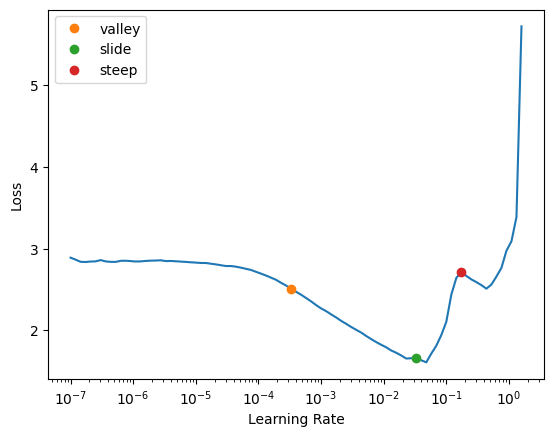

In [21]:
learner = Learner(dls, model=model, loss_func=CrossEntropyLossFlat(), metrics=error_rate)
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))
learner.fit_one_cycle(20, lr.valley)

In [22]:
learner.summary()

Sequential (Input shape: 16 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     16 x 8 x 55 x 55    
Conv2d                                    392        True      
BatchNorm2d                               16         True      
ReLU                                                           
____________________________________________________________________________
                     16 x 16 x 27 x 27   
Conv2d                                    1168       True      
BatchNorm2d                               32         True      
ReLU                                                           
____________________________________________________________________________
                     16 x 32 x 13 x 13   
Conv2d                                    4640       True      
BatchNorm2d                               64         True      
ReLU                                                           
___________________________________

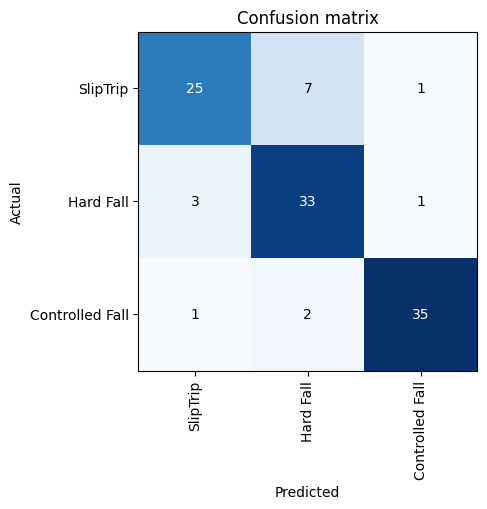

In [23]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [24]:
inter_plot.most_confused()

[('SlipTrip', 'Hard Fall', np.int64(7)),
 ('Hard Fall', 'SlipTrip', np.int64(3)),
 ('Controlled Fall', 'Hard Fall', np.int64(2)),
 ('SlipTrip', 'Controlled Fall', np.int64(1)),
 ('Hard Fall', 'Controlled Fall', np.int64(1)),
 ('Controlled Fall', 'SlipTrip', np.int64(1))]

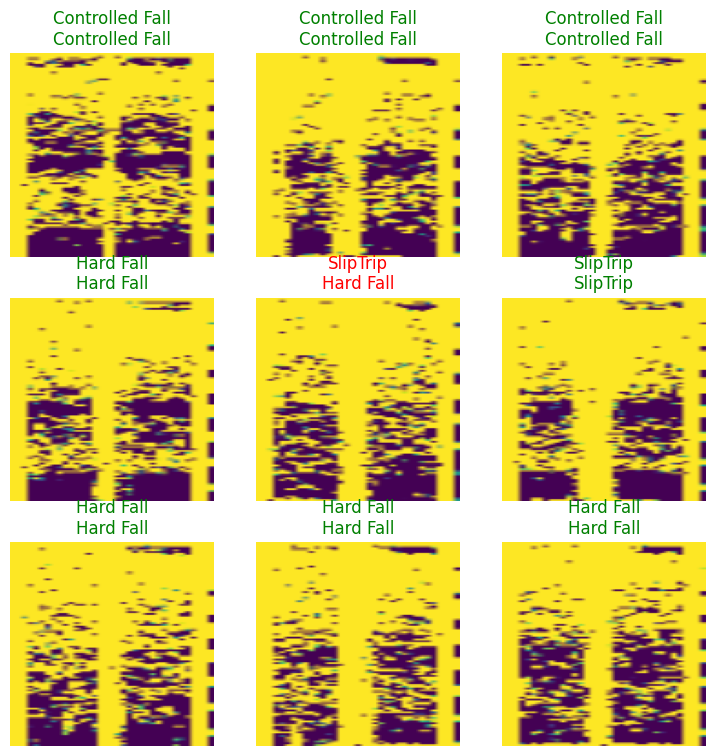

In [25]:
learner.show_results()

In [ ]:
if not learner:
    learner = load_learner("./models/classifier.pkl")

In [26]:
def get_x_test(i):
    arr = valid_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
        arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [27]:
learner.validate()

(#2) [0.3816926181316376,0.1388888955116272]

## Accuracy

This is the relationship between True labes, and all predicted labels. This determens how accurate the model is to predict the true lables. 

$$Accuracy = \frac{TP + TN}{TP + TN + FN + FP} $$

## Precision

The amount of True (or False) labels the model did find belonging to the positive class. The number of True Positives divided by True Positives plus False Positives.  

$$ Precision = \frac{TP}{TP + FP} $$

In [28]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 
    


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [30]:
y_pred, y_test = get_y_pred(learner, valid_spec)

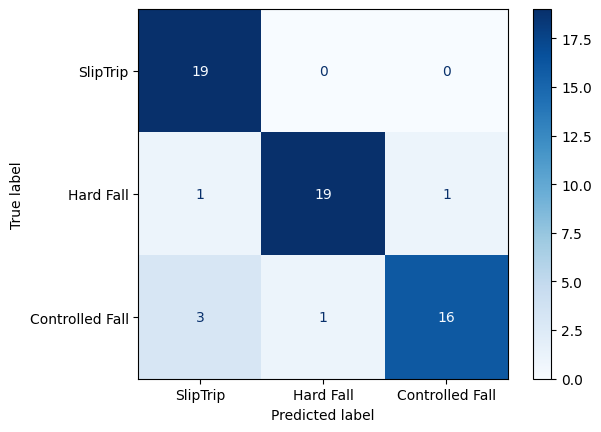

In [31]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [32]:
accuracy_score(y_test, y_pred)

0.9

In [33]:
precision_score(y_test, y_pred, average='weighted')

0.9078196930946291

In [34]:
recall_score(y_test, y_pred, average="weighted")

0.9

In [35]:
f1_score(y_test, y_pred, average="weighted")

0.8991864686986639

In [36]:
dir = Path('./models')

learner.path = dir

learner.export('classifier.pkl')